In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import os

# --- 1. Load Data (Using Standardized Template) ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    # Load necessary datasets using the specified path structure
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("Successfully loaded county-level employment and state policy data.")
except FileNotFoundError as e:
    print(f"ERROR: A file was not found in your Downloads folder. Please check the file names.")
    print(f"Details: {e}")
    exit()

# --- 2. Prepare and Merge Data ---

# Prepare employment data
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['statefips'] = employment_df['countyfips'].astype(str).str.zfill(5).str[:2].astype(int)

# Isolate the specific policy event: non-essential business closures
policy_event_df = policy_df[policy_df['nonessential_biz_first_closed'] == 1][['statefips', 'date']].copy()
policy_event_df.rename(columns={'date': 'event_date'}, inplace=True)
policy_event_df['event_date'] = pd.to_datetime(policy_event_df['event_date'])

# Merge the state-level event date onto the county-level employment data
panel_df = pd.merge(employment_df, policy_event_df, on='statefips', how='left')

# Define the analysis window around the March 2020 events
start_date = pd.to_datetime('2020-02-01')
end_date = pd.to_datetime('2020-04-25')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()

panel_df.set_index(['countyfips', 'date'], inplace=True)


# --- 3. Engineer Event Study Variables for Staggered Treatment ---

panel_df['event_time'] = (panel_df.index.get_level_values('date') - panel_df['event_date']).dt.days // 7

event_window = range(-4, 5)
reference_period = -1

exog_var_names = []
for week in event_window:
    if week == reference_period: continue
    var_name = f'T_{week}'
    panel_df[var_name] = (panel_df['event_time'] == week).astype(int)
    exog_var_names.append(var_name)


# --- 4. Run the Staggered Difference-in-Differences Model ---
print("\n--- Running Staggered DiD Model for Business Closures ---")

# CORRECTED: Drop rows with NaN in ANY of the model's columns BEFORE running the model.
# This ensures perfect alignment between the dependent and independent variables.
columns_for_model = ['emp_incq1'] + exog_var_names
panel_df.dropna(subset=columns_for_model, inplace=True)

# Define dependent and exogenous variables from the fully cleaned DataFrame
dependent = panel_df['emp_incq1']
exog = panel_df[exog_var_names]

mod = PanelOLS(dependent, exog, entity_effects=True, time_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print(result)

# --- 5. Plot the Results ---
coeffs = result.params
conf_int = result.conf_int()
coeffs.loc[f'T_{reference_period}'] = 0
conf_int.loc[f'T_{reference_period}'] = [0, 0]

plot_times = sorted([int(c.split('_')[1]) for c in coeffs.index])
coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
conf_int.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='maroon', capsize=5,
             label='Change in Low-Income Employment\n(Post-Closure vs. Pre-Closure)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Date of State Business Closure Order')

plt.title('Impact of Non-Essential Business Closures on Low-Income Employment (County Level)', fontsize=16)
plt.xlabel('Weeks Relative to State Closure Order', fontsize=12)
plt.ylabel('Change in Employment (Lowest Income Quartile)', fontsize=12)
plt.xticks(plot_times)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('business_closure_event_study.png')

print("\n--- Plot Generated: business_closure_event_study.png ---")

Successfully loaded county-level employment and state policy data.

--- Running Staggered DiD Model for Business Closures ---


ValueError: Length mismatch: Expected axis has 2843 elements, new values have 1 elements

In [ ]:
employment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525469 entries, 0 to 525468
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   year             525469 non-null  int64         
 1   month            525469 non-null  int64         
 2   day              525469 non-null  int64         
 3   countyfips       525469 non-null  int64         
 4   emp              525469 non-null  object        
 5   emp_incq1        525469 non-null  object        
 6   emp_incq2        525469 non-null  object        
 7   emp_incq3        525469 non-null  object        
 8   emp_incq4        525469 non-null  object        
 9   emp_incmiddle    525469 non-null  object        
 10  emp_incbelowmed  525469 non-null  object        
 11  emp_incabovemed  525469 non-null  object        
 12  date             525469 non-null  datetime64[ns]
 13  statefips        525469 non-null  int64         
dtypes: datetime64[ns](1)

In [ ]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   statefips                      672 non-null    int64 
 1   statename                      672 non-null    object
 2   date                           672 non-null    object
 3   policy_description             672 non-null    object
 4   schools_first_closed           672 non-null    int64 
 5   nonessential_biz_first_closed  672 non-null    int64 
 6   stayathome_first_start         672 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 36.9+ KB


Successfully loaded county-level employment and state policy data.

--- Running Staggered DiD Model for Business Closures ---
                          PanelOLS Estimation Summary                           
Dep. Variable:              emp_incq1   R-squared:                        0.0169
Estimator:                   PanelOLS   R-squared (Between):              0.0991
No. Observations:                9036   R-squared (Within):               0.1472
Date:                Fri, Oct 03 2025   R-squared (Overall):              0.1216
Time:                        19:40:49   Log-likelihood                    9967.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.717
Entities:                         753   P-value                           0.0000
Avg Obs:                       12.000   Distribution:                  F(8,8264)
Min Obs:                       12.000                           

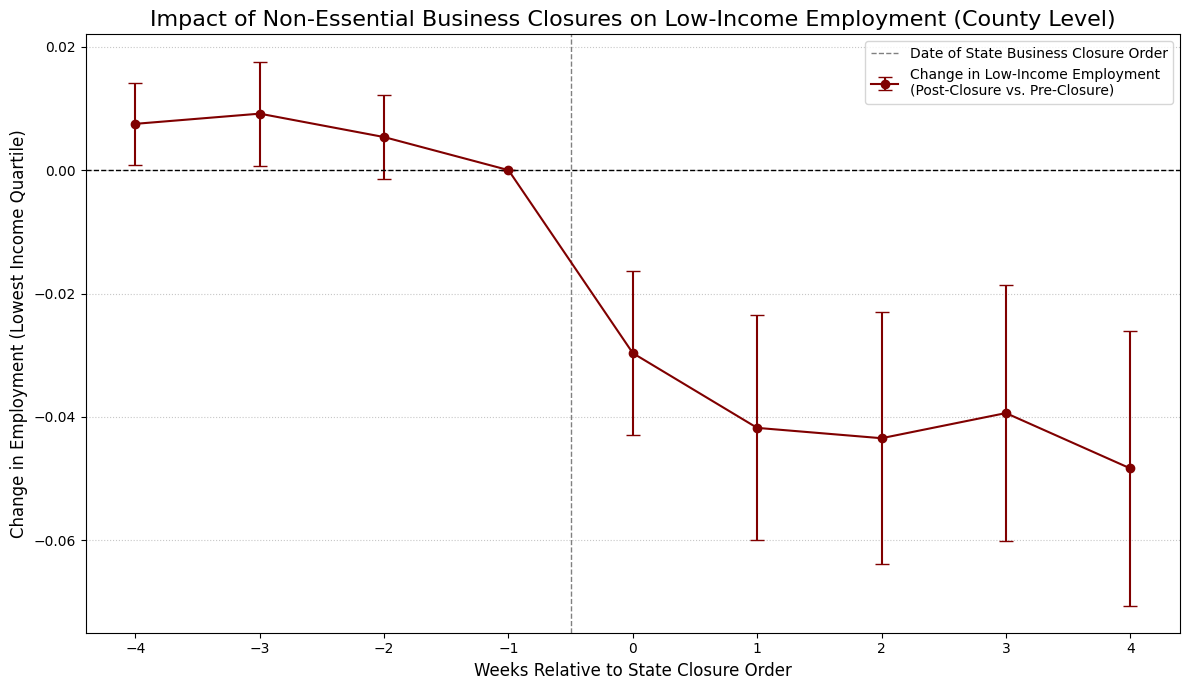

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import os

# --- 1. Load Data (Using Standardized Template) ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    # Load necessary datasets using the specified path structure
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("Successfully loaded county-level employment and state policy data.")
except FileNotFoundError as e:
    print(f"ERROR: A file was not found in your Downloads folder. Please check the file names.")
    print(f"Details: {e}")
    exit()

# --- 2. Prepare and Merge Data ---

# Prepare employment data
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['statefips'] = employment_df['countyfips'].astype(str).str.zfill(5).str[:2].astype(int)

# CORRECTED: Convert emp_incq1 from object to a numeric type.
employment_df['emp_incq1'] = pd.to_numeric(employment_df['emp_incq1'], errors='coerce')

# Isolate the specific policy event: non-essential business closures
policy_event_df = policy_df[policy_df['nonessential_biz_first_closed'] == 1][['statefips', 'date']].copy()
policy_event_df.rename(columns={'date': 'event_date'}, inplace=True)
policy_event_df['event_date'] = pd.to_datetime(policy_event_df['event_date'])

# Merge the state-level event date onto the county-level employment data
panel_df = pd.merge(employment_df, policy_event_df, on='statefips', how='left')

# Define the analysis window around the March 2020 events
start_date = pd.to_datetime('2020-02-01')
end_date = pd.to_datetime('2020-04-25')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()

panel_df.set_index(['countyfips', 'date'], inplace=True)


# --- 3. Engineer Event Study Variables for Staggered Treatment ---

panel_df['event_time'] = (panel_df.index.get_level_values('date') - panel_df['event_date']).dt.days // 7

event_window = range(-4, 5)
reference_period = -1

exog_var_names = []
for week in event_window:
    if week == reference_period: continue
    var_name = f'T_{week}'
    panel_df[var_name] = (panel_df['event_time'] == week).astype(int)
    exog_var_names.append(var_name)


# --- 4. Run the Staggered Difference-in-Differences Model ---
print("\n--- Running Staggered DiD Model for Business Closures ---")

# Drop rows with NaN in ANY of the model's columns BEFORE running the model.
columns_for_model = ['emp_incq1'] + exog_var_names
panel_df.dropna(subset=columns_for_model, inplace=True)

# Define dependent and exogenous variables from the fully cleaned DataFrame
dependent = panel_df['emp_incq1']
exog = panel_df[exog_var_names]

mod = PanelOLS(dependent, exog, entity_effects=True, time_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print(result)

# --- 5. Plot the Results ---
coeffs = result.params
conf_int = result.conf_int()
coeffs.loc[f'T_{reference_period}'] = 0
conf_int.loc[f'T_{reference_period}'] = [0, 0]

plot_times = sorted([int(c.split('_')[1]) for c in coeffs.index])
coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
conf_int.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='maroon', capsize=5,
             label='Change in Low-Income Employment\n(Post-Closure vs. Pre-Closure)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Date of State Business Closure Order')

plt.title('Impact of Non-Essential Business Closures on Low-Income Employment (County Level)', fontsize=16)
plt.xlabel('Weeks Relative to State Closure Order', fontsize=12)
plt.ylabel('Change in Employment (Lowest Income Quartile)', fontsize=12)
plt.xticks(plot_times)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('business_closure_event_study.png')

print("\n--- Plot Generated: business_closure_event_study.png ---")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import os

# --- 1. Load Data (Using Standardized Template) ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("Successfully loaded county-level employment and state policy data.")
except FileNotFoundError as e:
    print(f"ERROR: A file was not found in your Downloads folder. Please check the file names.")
    print(f"Details: {e}")
    exit()

# --- 2. Prepare and Merge Data ---

# Prepare employment data
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['emp_incq1'] = pd.to_numeric(employment_df['emp_incq1'], errors='coerce')
employment_df['statefips'] = employment_df['countyfips'].astype(str).str.zfill(5).str[:2].astype(int)

# Isolate the primary policy event: non-essential business closures
biz_closure_df = policy_df[policy_df['nonessential_biz_first_closed'] == 1][['statefips', 'date']].copy()
biz_closure_df.rename(columns={'date': 'event_date'}, inplace=True)
biz_closure_df['event_date'] = pd.to_datetime(biz_closure_df['event_date'])

# Isolate the interaction policy: stay-at-home orders
stay_home_df = policy_df[policy_df['stayathome_first_start'] == 1][['statefips']].copy()
stay_home_df['had_stayathome_order'] = 1
stay_home_df.drop_duplicates(subset=['statefips'], inplace=True)

# Merge both policy layers onto the county data
panel_df = pd.merge(employment_df, biz_closure_df, on='statefips', how='left')
panel_df = pd.merge(panel_df, stay_home_df, on='statefips', how='left')
panel_df['had_stayathome_order'].fillna(0, inplace=True) # Counties in states without a stay-at-home order get 0

# Define the analysis window
start_date = pd.to_datetime('2020-02-01')
end_date = pd.to_datetime('2020-04-25')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()
panel_df.set_index(['countyfips', 'date'], inplace=True)

# --- 3. Engineer Triple-Difference (DDD) Variables ---

panel_df['event_time'] = (panel_df.index.get_level_values('date') - panel_df['event_date']).dt.days // 7
event_window = range(-4, 5)
reference_period = -1

exog_var_names = []
# Create main event dummies AND the interaction dummies
for week in event_window:
    if week == reference_period: continue
    
    # Main effect of business closure (T_k)
    main_effect_var = f'T_{week}'
    panel_df[main_effect_var] = (panel_df['event_time'] == week).astype(int)
    exog_var_names.append(main_effect_var)

    # Interaction effect (T_k * Had_Stay_At_Home_Order)
    interaction_var = f'T_{week}_x_StayHome'
    panel_df[interaction_var] = panel_df[main_effect_var] * panel_df['had_stayathome_order']
    exog_var_names.append(interaction_var)

# Add the standalone dummy for having a stay-at-home order
exog_var_names.append('had_stayathome_order')

# --- 4. Run the Triple-Difference Model ---
print("\n--- Running Triple-Difference (DDD) Model ---")

# Clean data for the model
columns_for_model = ['emp_incq1'] + exog_var_names
panel_df.dropna(subset=columns_for_model, inplace=True)

dependent = panel_df['emp_incq1']
exog = panel_df[exog_var_names]

mod = PanelOLS(dependent, exog, entity_effects=True, time_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Interaction Effect Results (T_k * StayHome) ---")
# We only care about the interaction coefficients for our primary result
print(result.params.filter(like='_x_StayHome'))
print(result.pvalues.filter(like='_x_StayHome'))


# --- 5. Plot the Interaction Effect ---
coeffs = result.params.filter(like='_x_StayHome')
conf_int = result.conf_int().filter(like='_x_StayHome', axis=0)
coeffs.loc[f'T_{reference_period}_x_StayHome'] = 0
conf_int.loc[f'T_{reference_period}_x_StayHome'] = [0, 0]

def get_week(index_val):
    return int(index_val.split('_')[1])

plot_times = sorted([get_week(c) for c in coeffs.index])
coeffs.index = coeffs.index.map(get_week)
conf_int.index = conf_int.index.map(get_week)
coeffs.sort_index(inplace=True)
conf_int.sort_index(inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='rebeccapurple', capsize=5,
             label='Additional Employment Change from Stay-at-Home Order')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Date of State Business Closure Order')

plt.title('Interaction Effect: Business Closures and Stay-at-Home Orders', fontsize=16)
plt.xlabel('Weeks Relative to State Business Closure Order', fontsize=12)
plt.ylabel('Additional Change in Low-Income Employment', fontsize=12)
plt.xticks(plot_times)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('interaction_effect_study.png')

print("\n--- Plot Generated: interaction_effect_study.png ---")

Successfully loaded county-level employment and state policy data.

--- Running Triple-Difference (DDD) Model ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_72644/275926356.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  panel_df['had_stayathome_order'].fillna(0, inplace=True) # Counties in states without a stay-at-home order get 0


AbsorbingEffectError: 
The model cannot be estimated. The included effects have fully absorbed
one or more of the variables. This occurs when one or more of the dependent
variable is perfectly explained using the effects included in the model.

The following variables or variable combinations have been fully absorbed
or have become perfectly collinear after effects are removed:

          had_stayathome_order

Set drop_absorbed=True to automatically drop absorbed variables.


Successfully loaded county-level employment and state policy data.

--- Running Triple-Difference (DDD) Model ---

--- Interaction Effect Results (T_k * StayHome) ---
Coefficients:
T_-4_x_StayHome    0.004119
T_-3_x_StayHome   -0.002527
T_-2_x_StayHome   -0.014938
T_0_x_StayHome    -0.078186
T_1_x_StayHome    -0.114027
T_2_x_StayHome    -0.124853
T_3_x_StayHome    -0.125377
T_4_x_StayHome    -0.094873
Name: parameter, dtype: float64

P-Values:
T_-4_x_StayHome    0.564277
T_-3_x_StayHome    0.774686
T_-2_x_StayHome    0.216519
T_0_x_StayHome     0.008840
T_1_x_StayHome     0.000755
T_2_x_StayHome     0.000143
T_3_x_StayHome     0.000069
T_4_x_StayHome     0.027369
Name: pvalue, dtype: float64

--- Plot Generated: interaction_effect_study.png ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_65507/220332148.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  panel_df['had_stayathome_order'].fillna(0, inplace=True)


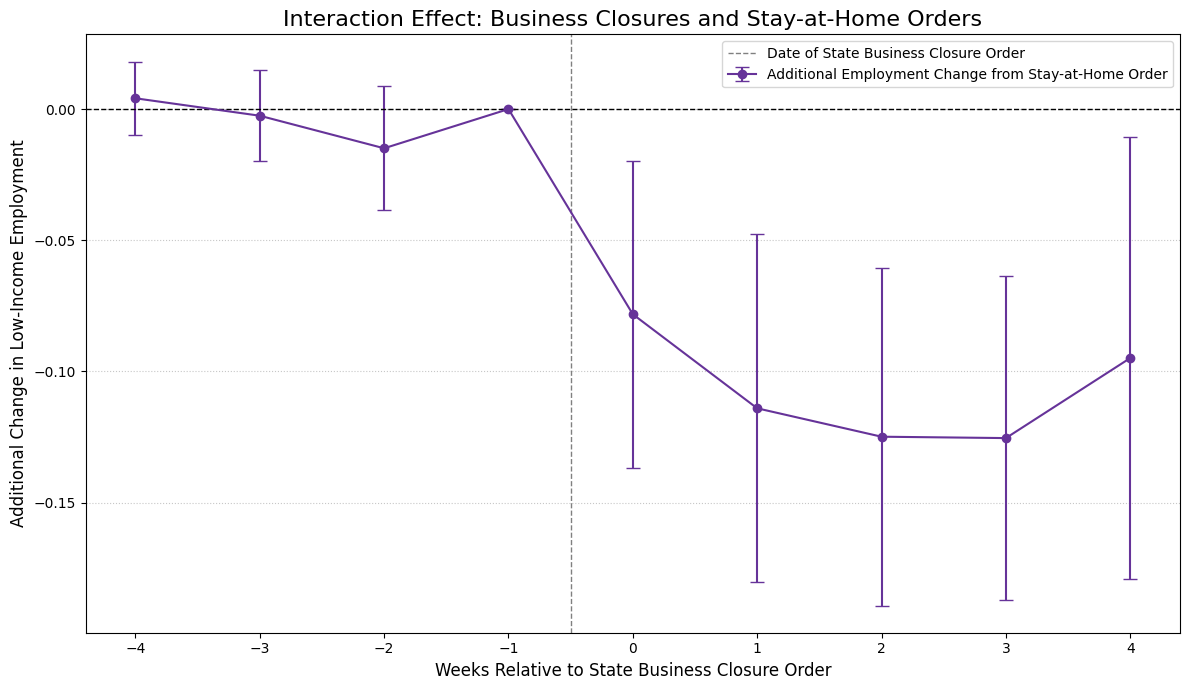

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import os

# --- 1. Load Data (Using Standardized Template) ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("Successfully loaded county-level employment and state policy data.")
except FileNotFoundError as e:
    print(f"ERROR: A file was not found in your Downloads folder. Please check the file names.")
    print(f"Details: {e}")
    exit()

# --- 2. Prepare and Merge Data ---

# Prepare employment data
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['emp_incq1'] = pd.to_numeric(employment_df['emp_incq1'], errors='coerce')
employment_df['statefips'] = employment_df['countyfips'].astype(str).str.zfill(5).str[:2].astype(int)

# Isolate the primary policy event: non-essential business closures
biz_closure_df = policy_df[policy_df['nonessential_biz_first_closed'] == 1][['statefips', 'date']].copy()
biz_closure_df.rename(columns={'date': 'event_date'}, inplace=True)
biz_closure_df['event_date'] = pd.to_datetime(biz_closure_df['event_date'])

# Isolate the interaction policy: stay-at-home orders
stay_home_df = policy_df[policy_df['stayathome_first_start'] == 1][['statefips']].copy()
stay_home_df['had_stayathome_order'] = 1
stay_home_df.drop_duplicates(subset=['statefips'], inplace=True)

# Merge both policy layers onto the county data
panel_df = pd.merge(employment_df, biz_closure_df, on='statefips', how='left')
panel_df = pd.merge(panel_df, stay_home_df, on='statefips', how='left')
panel_df['had_stayathome_order'].fillna(0, inplace=True)

# Define the analysis window
start_date = pd.to_datetime('2020-02-01')
end_date = pd.to_datetime('2020-04-25')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()
panel_df.set_index(['countyfips', 'date'], inplace=True)

# --- 3. Engineer Triple-Difference (DDD) Variables ---

panel_df['event_time'] = (panel_df.index.get_level_values('date') - panel_df['event_date']).dt.days // 7
event_window = range(-4, 5)
reference_period = -1

exog_var_names = []
for week in event_window:
    if week == reference_period: continue
    
    main_effect_var = f'T_{week}'
    panel_df[main_effect_var] = (panel_df['event_time'] == week).astype(int)
    exog_var_names.append(main_effect_var)

    interaction_var = f'T_{week}_x_StayHome'
    panel_df[interaction_var] = panel_df[main_effect_var] * panel_df['had_stayathome_order']
    exog_var_names.append(interaction_var)

# --- 4. Run the Triple-Difference Model ---
print("\n--- Running Triple-Difference (DDD) Model ---")

columns_for_model = ['emp_incq1'] + exog_var_names
panel_df.dropna(subset=columns_for_model, inplace=True)

dependent = panel_df['emp_incq1']
# CORRECTED: The standalone 'had_stayathome_order' is removed from the exogenous variables.
exog = panel_df[exog_var_names] 

mod = PanelOLS(dependent, exog, entity_effects=True, time_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Interaction Effect Results (T_k * StayHome) ---")
print("Coefficients:")
print(result.params.filter(like='_x_StayHome'))
print("\nP-Values:")
print(result.pvalues.filter(like='_x_StayHome'))


# --- 5. Plot the Interaction Effect ---
coeffs = result.params.filter(like='_x_StayHome')
conf_int = result.conf_int().filter(like='_x_StayHome', axis=0)
coeffs.loc[f'T_{reference_period}_x_StayHome'] = 0
conf_int.loc[f'T_{reference_period}_x_StayHome'] = [0, 0]

def get_week(index_val):
    return int(index_val.split('_')[1])

plot_times = sorted([get_week(c) for c in coeffs.index])
coeffs.index = coeffs.index.map(get_week)
conf_int.index = conf_int.index.map(get_week)
coeffs.sort_index(inplace=True)
conf_int.sort_index(inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='rebeccapurple', capsize=5,
             label='Additional Employment Change from Stay-at-Home Order')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Date of State Business Closure Order')

plt.title('Interaction Effect: Business Closures and Stay-at-Home Orders', fontsize=16)
plt.xlabel('Weeks Relative to State Business Closure Order', fontsize=12)
plt.ylabel('Additional Change in Low-Income Employment', fontsize=12)
plt.xticks(plot_times)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('interaction_effect_study.png')

print("\n--- Plot Generated: interaction_effect_study.png ---")

Successfully loaded county-level employment and state policy data.


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_83803/1634930697.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  panel_df['had_stayathome_order'].fillna(0, inplace=True)



--- Running Triple-Difference (DDD) Model ---

--- Interaction Effect Results (T_k * StayHome) ---
Coefficients:
T_-8_x_StayHome    0.042013
T_-7_x_StayHome    0.048076
T_-6_x_StayHome    0.062534
T_-5_x_StayHome    0.054056
T_-4_x_StayHome    0.043615
T_-3_x_StayHome    0.042975
T_-2_x_StayHome    0.061216
T_0_x_StayHome     0.004346
T_1_x_StayHome    -0.054193
T_2_x_StayHome    -0.084512
T_3_x_StayHome    -0.092442
T_4_x_StayHome    -0.105124
T_5_x_StayHome    -0.117092
T_6_x_StayHome    -0.108362
T_7_x_StayHome    -0.093887
T_8_x_StayHome    -0.071640
Name: parameter, dtype: float64

P-Values:
T_-8_x_StayHome    1.157118e-02
T_-7_x_StayHome    1.977514e-03
T_-6_x_StayHome    8.699221e-04
T_-5_x_StayHome    2.797316e-03
T_-4_x_StayHome    1.845673e-03
T_-3_x_StayHome    2.754659e-03
T_-2_x_StayHome    6.592238e-04
T_0_x_StayHome     8.823877e-01
T_1_x_StayHome     6.462158e-02
T_2_x_StayHome     2.436985e-03
T_3_x_StayHome     5.261250e-04
T_4_x_StayHome     1.584087e-05
T_5_x_StayH

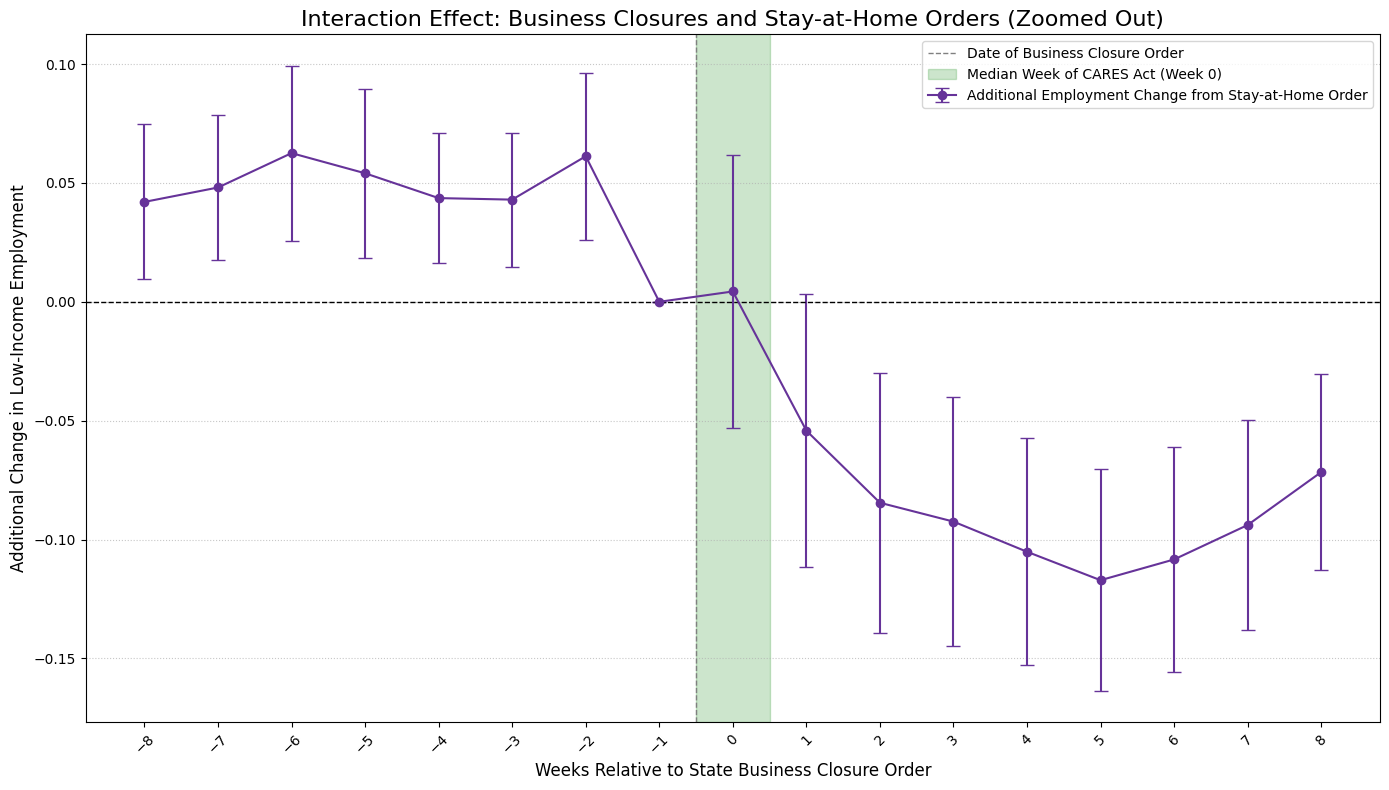

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import os

# --- 1. Load Data (Using Standardized Template) ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("Successfully loaded county-level employment and state policy data.")
except FileNotFoundError as e:
    print(f"ERROR: A file was not found in your Downloads folder. Please check the file names.")
    print(f"Details: {e}")
    exit()

# --- 2. Prepare and Merge Data ---

# Prepare employment data
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['emp_incq1'] = pd.to_numeric(employment_df['emp_incq1'], errors='coerce')
employment_df['statefips'] = employment_df['countyfips'].astype(str).str.zfill(5).str[:2].astype(int)

# Isolate policy events
biz_closure_df = policy_df[policy_df['nonessential_biz_first_closed'] == 1][['statefips', 'date']].copy()
biz_closure_df.rename(columns={'date': 'event_date'}, inplace=True)
biz_closure_df['event_date'] = pd.to_datetime(biz_closure_df['event_date'])

stay_home_df = policy_df[policy_df['stayathome_first_start'] == 1][['statefips']].copy()
stay_home_df['had_stayathome_order'] = 1
stay_home_df.drop_duplicates(subset=['statefips'], inplace=True)

# Merge both policy layers onto the county data
panel_df = pd.merge(employment_df, biz_closure_df, on='statefips', how='left')
panel_df = pd.merge(panel_df, stay_home_df, on='statefips', how='left')
panel_df['had_stayathome_order'].fillna(0, inplace=True)

# UPDATED: "Zoom out" by widening the date window
start_date = pd.to_datetime('2020-01-15')
end_date = pd.to_datetime('2020-05-31')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()
panel_df.set_index(['countyfips', 'date'], inplace=True)

# --- 3. Engineer DDD Variables ---

panel_df['event_time'] = (panel_df.index.get_level_values('date') - panel_df['event_date']).dt.days // 7

# UPDATED: "Zoom out" by widening the event window
event_window = range(-8, 9)
reference_period = -1

exog_var_names = []
for week in event_window:
    if week == reference_period: continue
    
    main_effect_var = f'T_{week}'
    panel_df[main_effect_var] = (panel_df['event_time'] == week).astype(int)
    exog_var_names.append(main_effect_var)

    interaction_var = f'T_{week}_x_StayHome'
    panel_df[interaction_var] = panel_df[main_effect_var] * panel_df['had_stayathome_order']
    exog_var_names.append(interaction_var)

# --- 4. Run the Triple-Difference Model ---
print("\n--- Running Triple-Difference (DDD) Model ---")

columns_for_model = ['emp_incq1'] + exog_var_names
panel_df.dropna(subset=columns_for_model, inplace=True)

dependent = panel_df['emp_incq1']
exog = panel_df[exog_var_names]

# CORRECTED: The model runs with entity_effects but without time_effects to fix the rank error.
mod = PanelOLS(dependent, exog, entity_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Interaction Effect Results (T_k * StayHome) ---")
print("Coefficients:")
print(result.params.filter(like='_x_StayHome'))
print("\nP-Values:")
print(result.pvalues.filter(like='_x_StayHome'))

# --- 5. Plot the Interaction Effect ---
coeffs = result.params.filter(like='_x_StayHome')
conf_int = result.conf_int().filter(like='_x_StayHome', axis=0)
coeffs.loc[f'T_{reference_period}_x_StayHome'] = 0
conf_int.loc[f'T_{reference_period}_x_StayHome'] = [0, 0]

def get_week(index_val):
    return int(index_val.split('_')[1])

plot_times = sorted([get_week(c) for c in coeffs.index])
coeffs.index = coeffs.index.map(get_week)
conf_int.index = conf_int.index.map(get_week)
coeffs.sort_index(inplace=True)
conf_int.sort_index(inplace=True)

# Calculate the median relative week for the CARES Act
CARES_ACT_DATE = pd.to_datetime('2020-03-27')
cares_relative_week = np.floor((CARES_ACT_DATE - panel_df['event_date']).dt.days / 7).median()
print(f"\nMedian relative week of CARES Act signing: {cares_relative_week}")

plt.figure(figsize=(14, 8))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='rebeccapurple', capsize=5,
             label='Additional Employment Change from Stay-at-Home Order')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Date of Business Closure Order')

# NEW: Add a shaded region for the CARES Act
plt.axvspan(cares_relative_week - 0.5, cares_relative_week + 0.5, color='green', alpha=0.2,
            label=f'Median Week of CARES Act (Week {int(cares_relative_week)})')

plt.title('Interaction Effect: Business Closures and Stay-at-Home Orders (Zoomed Out)', fontsize=16)
plt.xlabel('Weeks Relative to State Business Closure Order', fontsize=12)
plt.ylabel('Additional Change in Low-Income Employment', fontsize=12)
plt.xticks(plot_times, rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('interaction_effect_study_zoomed.png')

print("\n--- Plot Generated: interaction_effect_study_zoomed.png ---")

In [3]:
panel_df

,,year,month,day,emp,emp_incq1,emp_incq2,emp_incq3,emp_incq4,emp_incmiddle,emp_incbelowmed,...,T_4,T_4_x_StayHome,T_5,T_5_x_StayHome,T_6,T_6_x_StayHome,T_7,T_7_x_StayHome,T_8,T_8_x_StayHome
countyfips,date,,,,,,,,,,,,,,,,,,,,,
1015,2020-01-17,2020,1,17,.168,0.344000,.0186,.,.,.032,.205,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1073,2020-01-17,2020,1,17,-.000842,-0.000121,-.0046,.0054,-.00553,.0000724,-.00208,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1077,2020-01-17,2020,1,17,-.0139,-0.074900,.,-.0082,.0168,-.0131,-.0543,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1089,2020-01-17,2020,1,17,.00466,0.010000,.00259,-.0000499,.00618,.00127,.00635,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1097,2020-01-17,2020,1,17,-.00414,-0.023800,-.00261,.0161,-.00964,.00697,-.013,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55127,2020-05-29,2020,5,29,-.101,-0.257000,-.223,.0126,.106,-.112,-.235,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
55131,2020-05-29,2020,5,29,-.0674,-0.221000,-.096,-.0318,.0575,-.0639,-.135,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
55133,2020-05-29,2020,5,29,-.0645,-0.192000,-.12,-.0189,.00816,-.0621,-.145,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
from scipy.stats import chi2

# -----------------------
# 1) Load Data
# -----------------------
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("✅ Successfully loaded all CSVs from ~/Downloads/")
except FileNotFoundError as e:
    print(f"ERROR: {e}")
    raise

# -----------------------
# 2) Clean / Weekly-ize Inputs
# -----------------------
# Employment
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year','month','day']])
employment_df['date'] = employment_df['date'] - pd.to_timedelta(employment_df['date'].dt.dayofweek, unit='d') + pd.to_timedelta(6, unit='d')
employment_df['statefips'] = employment_df['countyfips'].astype(str).str.zfill(5).str[:2].astype(int)

emp_cols = [
    'emp', 'emp_incq1', 'emp_incq2', 'emp_incq3', 'emp_incq4',
    'emp_incmiddle', 'emp_incbelowmed', 'emp_incabovemed',
    'emp_ss40', 'emp_ss60', 'emp_ss65', 'emp_ss70',
    'emp_retail', 'emp_retail_inclow', 'emp_retail_incmiddle', 'emp_retail_inchigh',
    'emp_s72'
]
for c in emp_cols:
    if c in employment_df.columns:
        employment_df[c] = pd.to_numeric(employment_df[c], errors='coerce')

# COVID
covid_df['date'] = pd.to_datetime(covid_df[['year','month','day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

# Policy
policy_df['date'] = pd.to_datetime(policy_df['date'], errors='coerce')

print("✅ Data cleaned and weeklyized.")

# -----------------------
# 3) Identify Early UI Cut Treatment Dates
# -----------------------
federal_expiration_date = pd.to_datetime('2021-09-01')

mask_exact = policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
if mask_exact.any():
    early_terminators = policy_df[mask_exact & (policy_df['date'] < federal_expiration_date)].copy()
    print(f"Found {early_terminators['statefips'].nunique()} states using exact phrase match.")
else:
    mask_ui = policy_df['policy_description'].str.contains('ui|unemployment|benefit|pua|peuc', case=False, na=False)
    mask_end = policy_df['policy_description'].str.contains('end|ended|terminate|terminated|cut|stop', case=False, na=False)
    early_terminators = policy_df[mask_ui & mask_end & (policy_df['date'] < federal_expiration_date)].copy()
    print(f"Fallback keyword search found {early_terminators['statefips'].nunique()} states.")

ui_cut_df = early_terminators.groupby('statefips', as_index=False)['date'].min().rename(columns={'date':'treatment_date'})
ui_cut_df['treatment_date'] = pd.to_datetime(ui_cut_df['treatment_date'], errors='coerce')

# -----------------------
# 4) Merge to Build Panel
# -----------------------
panel_df = pd.merge(employment_df, weekly_covid, on=['statefips','date'], how='inner')
panel_df = pd.merge(panel_df, ui_cut_df[['statefips','treatment_date']], on='statefips', how='left')

start_date = pd.to_datetime('2021-04-01')
end_date   = pd.to_datetime('2021-10-31')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()
panel_df.dropna(subset=['covid_severity'], inplace=True)

print("✅ Panel merged. Shape:", panel_df.shape)



/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_72663/2185815118.py:15: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


✅ Successfully loaded all CSVs from ~/Downloads/
✅ Data cleaned and weeklyized.
Found 14 states using exact phrase match.
✅ Panel merged. Shape: (58807, 16)


✅ Event-study features engineered.


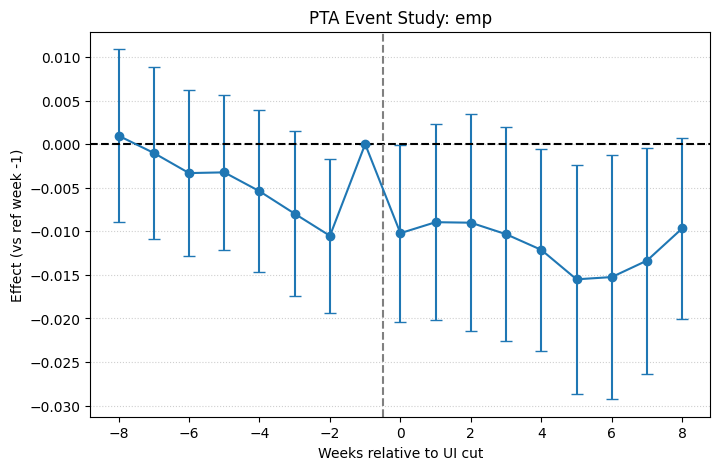

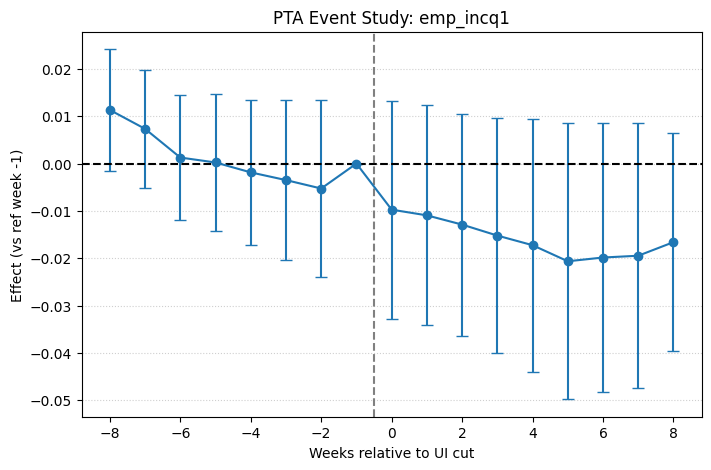

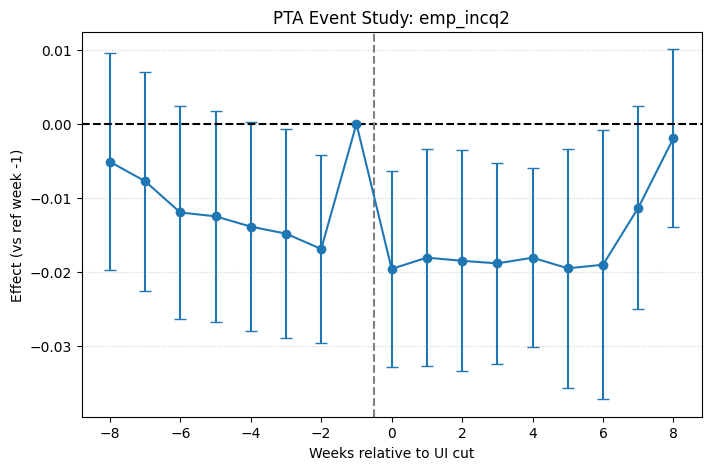

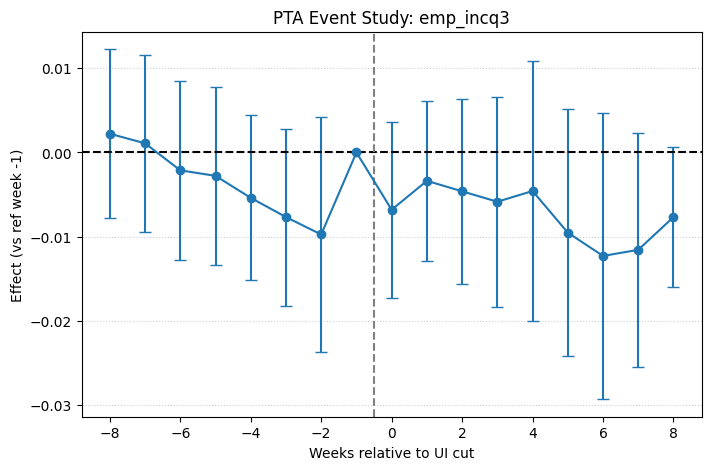

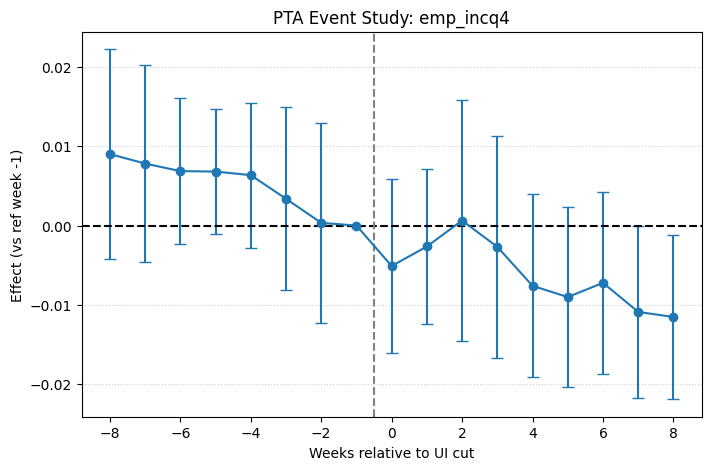

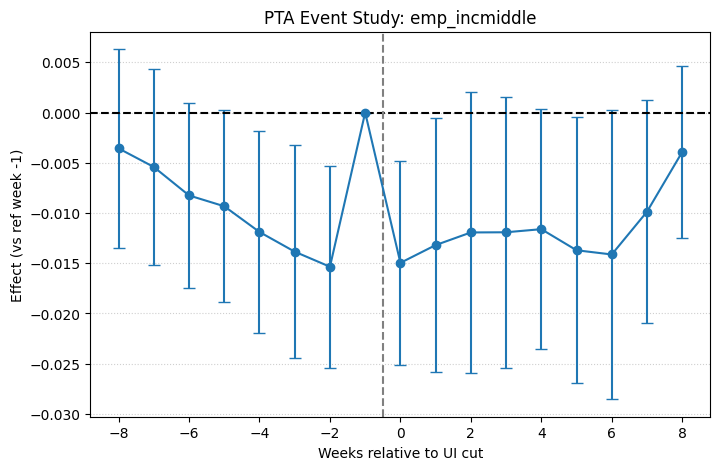

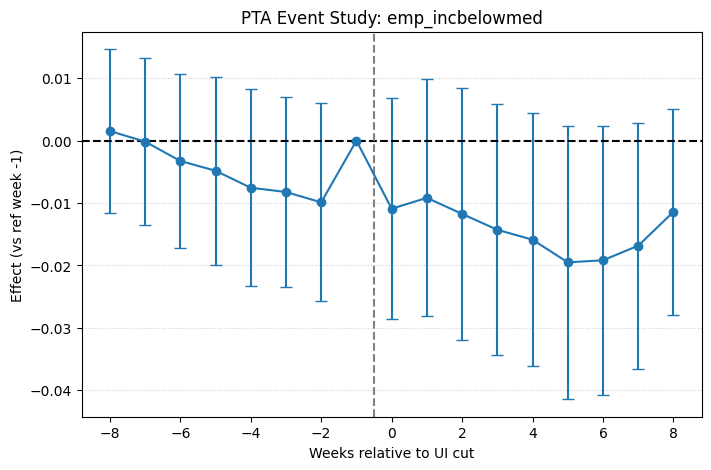

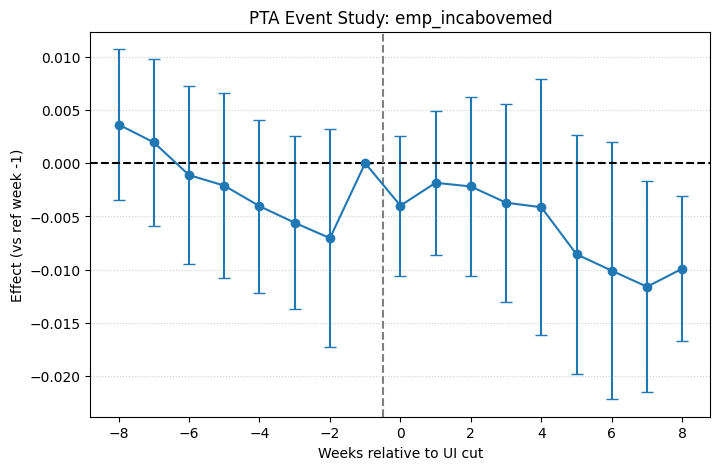

,variable,n_obs,any_pre_sig,pre_pvals
0,emp,36952,True,"{'T_-8': 0.8495376743532592, 'T_-7': 0.8403351..."
1,emp_incq1,23343,False,"{'T_-8': 0.08354014486778216, 'T_-7': 0.249438..."
2,emp_incq2,26753,True,"{'T_-8': 0.4932560625747593, 'T_-7': 0.3045099..."
3,emp_incq3,24304,False,"{'T_-8': 0.6642084016693337, 'T_-7': 0.8392628..."
4,emp_incq4,18755,False,"{'T_-8': 0.1813538187815511, 'T_-7': 0.2187732..."
5,emp_incmiddle,31992,True,"{'T_-8': 0.47874589630794695, 'T_-7': 0.275614..."
6,emp_incbelowmed,32333,False,"{'T_-8': 0.8174263063799467, 'T_-7': 0.9820552..."
7,emp_incabovemed,27652,False,"{'T_-8': 0.31492020647081764, 'T_-7': 0.626977..."


In [ ]:
# -----------------------
# 5) Event-Study Variables
# -----------------------
panel_df['is_treated_state'] = (~panel_df['treatment_date'].isna()).astype(int)
panel_df['post_treatment'] = (panel_df['date'] > panel_df['treatment_date']).astype(int)
panel_df['Policy_DiD'] = panel_df['is_treated_state'] * panel_df['post_treatment']

# event_time in whole weeks
panel_df['event_time'] = ((panel_df['date'] - panel_df['treatment_date']).dt.days // 7)

event_window = list(range(-8, 9))
reference_period = -1
for w in event_window:
    if w == reference_period: 
        continue
    col = f"T_{w}"
    panel_df[col] = (panel_df['event_time'] == w).fillna(False).astype(int)

panel_df.set_index(['statefips','date'], inplace=True)
print("✅ Event-study features engineered.")

# -----------------------
# 6) Run PTA Tests Loop (display results inline, no CSV)
# -----------------------
from IPython.display import display

out_summary = []

for emp_var in emp_cols:
    if emp_var not in panel_df.columns:
        continue
    
    df = panel_df[[emp_var] + [f"T_{w}" for w in event_window if w != reference_period] + ['covid_severity']].dropna()
    if df.empty: 
        continue
    
    y = df[emp_var]
    X = df.drop(columns=[emp_var])
    mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    # Pre-trend results
    pre_vars = [f"T_{w}" for w in event_window if w < 0 and w != reference_period and f"T_{w}" in res.params.index]
    pre_coefs = res.params.loc[pre_vars] if pre_vars else pd.Series(dtype=float)
    pre_pvals = res.pvalues.loc[pre_vars] if pre_vars else pd.Series(dtype=float)
    
    any_pre_sig = (pre_pvals < 0.05).any() if not pre_pvals.empty else False
    
    out_summary.append({
        "variable": emp_var,
        "n_obs": res.nobs,
        "any_pre_sig": any_pre_sig,
        "pre_pvals": pre_pvals.to_dict()
    })
    
    # --- Plot inline ---
    coeffs = res.params.filter(like="T_")
    conf = res.conf_int().filter(like="T_", axis=0)
    coeffs.loc[f"T_{reference_period}"] = 0
    conf.loc[f"T_{reference_period}"] = [0,0]
    
    weeks = [int(c.split('_')[1]) for c in coeffs.index]
    coeffs.index = weeks
    conf.index = weeks
    coeffs = coeffs.sort_index()
    conf = conf.sort_index()
    
    plt.figure(figsize=(8,5))
    plt.errorbar(coeffs.index, coeffs, 
                 yerr=[coeffs - conf.iloc[:,0], conf.iloc[:,1] - coeffs],
                 fmt='o-', capsize=4)
    plt.axhline(0, color='k', linestyle='--')
    plt.axvline(-0.5, color='gray', linestyle='--')
    plt.title(f'PTA Event Study: {emp_var}')
    plt.xlabel("Weeks relative to UI cut")
    plt.ylabel("Effect (vs ref week -1)")
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

# -----------------------
# 7) Display Summary Table
# -----------------------
summary_df = pd.DataFrame(out_summary)
display(summary_df)


In [ ]:
from linearmodels.panel import PanelOLS

# Restrict to rows with emp_incq1 and Policy_DiD defined
df = panel_df[['emp_incq1', 'Policy_DiD', 'covid_severity']].dropna()

y = df['emp_incq1']
X = df[['Policy_DiD', 'covid_severity']]

# TWFE: state & time effects
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res)
print("\nPolicy effect (Policy_DiD coefficient):", res.params['Policy_DiD'])
print("P-value:", res.pvalues['Policy_DiD'])


                          PanelOLS Estimation Summary                           
Dep. Variable:              emp_incq1   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):              0.0403
No. Observations:               23343   R-squared (Within):               0.0036
Date:                Fri, Oct 03 2025   R-squared (Overall):              0.0222
Time:                        19:46:32   Log-likelihood                    5142.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.2251
Entities:                          51   P-value                           0.0146
Avg Obs:                       457.71   Distribution:                 F(2,23260)
Min Obs:                       31.000                                           
Max Obs:                       1736.0   F-statistic (robust):             2.5650
                            

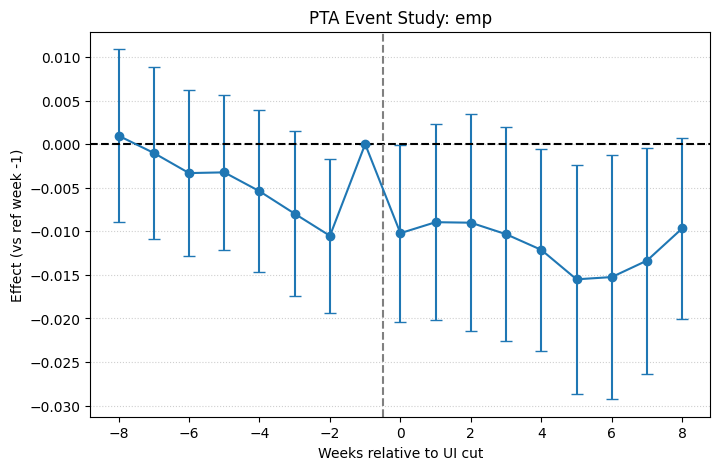

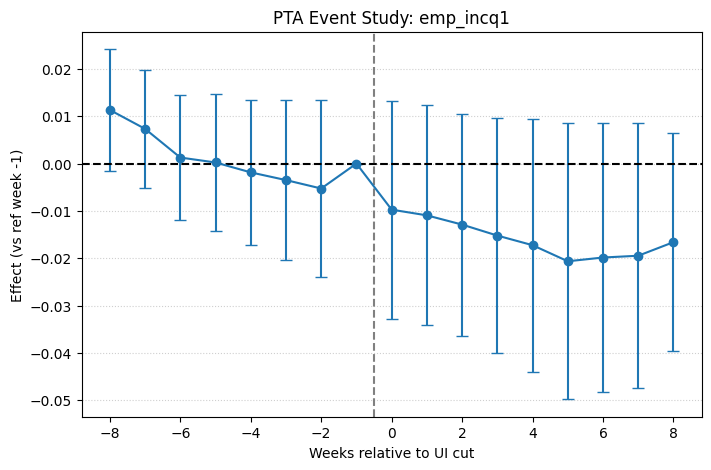

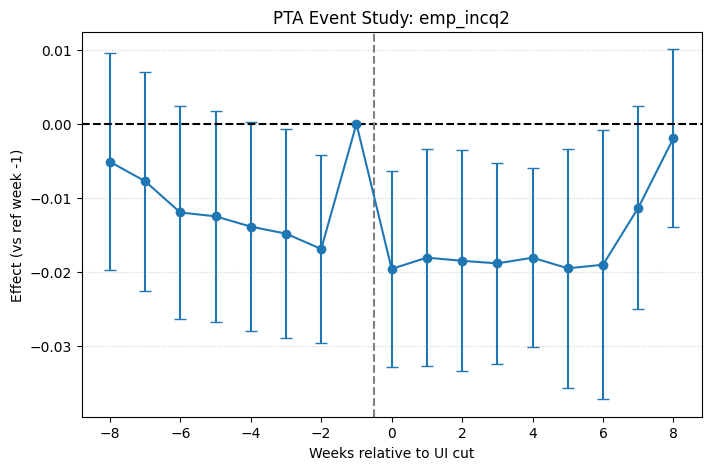

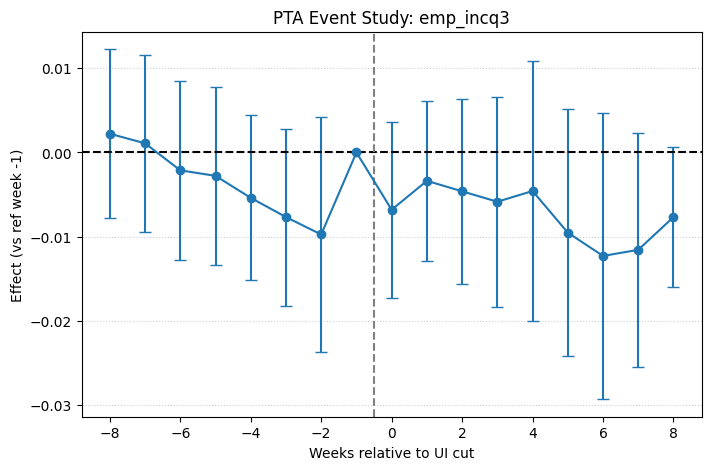

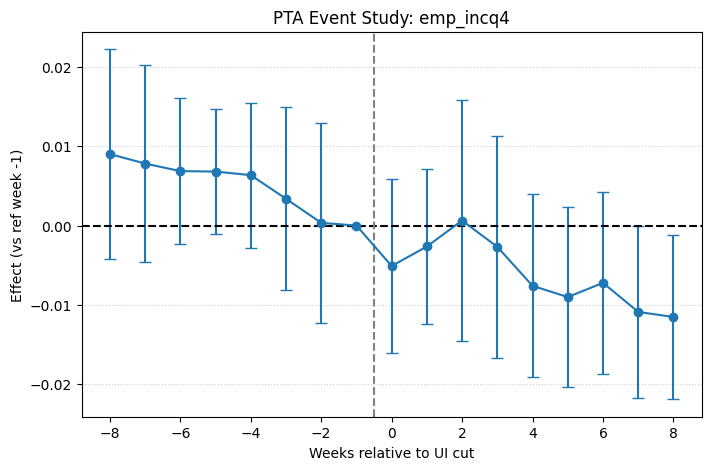

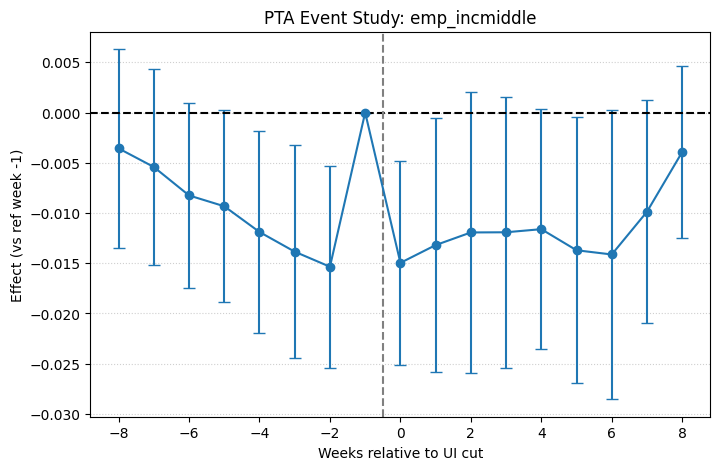

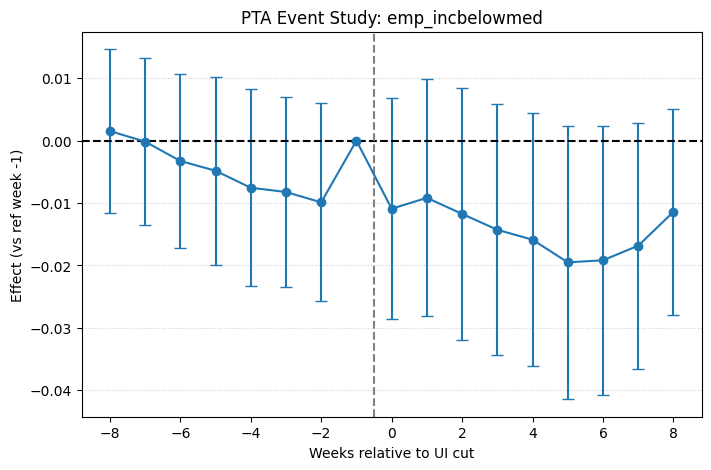

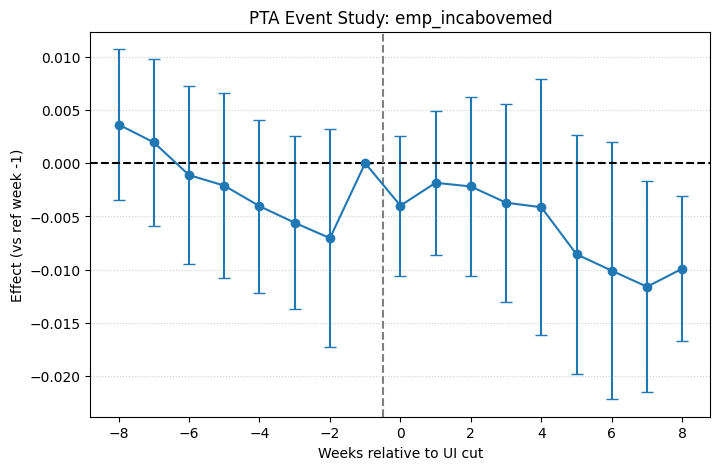

=== Variable: emp | Observations: 36952 | Any pre-trend sig: True ===


,event_week,coef,std_err,ci_lower,ci_upper,pval
0,T_-8,0.000961,0.005065,-0.008967,0.010889,0.849538
1,T_-7,-0.001017,0.005047,-0.010909,0.008875,0.840335
2,T_-6,-0.003325,0.004876,-0.012883,0.006233,0.495309
3,T_-5,-0.003242,0.004538,-0.012137,0.005654,0.475069
4,T_-4,-0.005406,0.004752,-0.014719,0.003907,0.255254
5,T_-3,-0.007990,0.004839,-0.017475,0.001494,0.098697
6,T_-2,-0.010524,0.004520,-0.019383,-0.001664,0.019902
7,T_0,-0.010220,0.005182,-0.020377,-0.000063,0.048593
8,T_1,-0.008960,0.005723,-0.020177,0.002257,0.117425
9,T_2,-0.009018,0.006355,-0.021474,0.003437,0.155860


=== Variable: emp_incq1 | Observations: 23343 | Any pre-trend sig: False ===


,event_week,coef,std_err,ci_lower,ci_upper,pval
0,T_-8,0.011327,0.006545,-0.001502,0.024157,0.083540
1,T_-7,0.007339,0.006372,-0.005151,0.019829,0.249438
2,T_-6,0.001275,0.006752,-0.011959,0.014508,0.850251
3,T_-5,0.000232,0.007339,-0.014152,0.014617,0.974751
4,T_-4,-0.001860,0.007832,-0.017210,0.013491,0.812292
5,T_-3,-0.003487,0.008665,-0.020472,0.013497,0.687347
6,T_-2,-0.005267,0.009590,-0.024063,0.013530,0.582868
7,T_0,-0.009732,0.011756,-0.032775,0.013311,0.407777
8,T_1,-0.010938,0.011854,-0.034172,0.012296,0.356161
9,T_2,-0.012888,0.011972,-0.036353,0.010577,0.281683


=== Variable: emp_incq2 | Observations: 26753 | Any pre-trend sig: True ===


...

,event_week,coef,std_err,ci_lower,ci_upper,pval
0,T_-8,-0.003569,0.005038,-0.013443,0.006306,0.478746
1,T_-7,-0.005419,0.004971,-0.015162,0.004323,0.275615
2,T_-6,-0.008253,0.004719,-0.017502,0.000997,0.080340
3,T_-5,-0.009331,0.004873,-0.018881,0.000220,0.055512
4,T_-4,-0.011893,0.005153,-0.021992,-0.001793,0.021009
5,T_-3,-0.013853,0.005408,-0.024452,-0.003254,0.010420
6,T_-2,-0.015351,0.005141,-0.025427,-0.005275,0.002827
7,T_0,-0.014965,0.005164,-0.025086,-0.004844,0.003756
8,T_1,-0.013197,0.006459,-0.025857,-0.000536,0.041057
9,T_2,-0.011937,0.007130,-0.025912,0.002038,0.094097


=== Variable: emp_incbelowmed | Observations: 32333 | Any pre-trend sig: False ===


,event_week,coef,std_err,ci_lower,ci_upper,pval
0,T_-8,0.001544,0.006690,-0.011568,0.014657,0.817426
1,T_-7,-0.000153,0.006807,-0.013494,0.013188,0.982055
2,T_-6,-0.003246,0.007119,-0.017199,0.010707,0.648397
3,T_-5,-0.004823,0.007703,-0.019922,0.010275,0.531226
4,T_-4,-0.007544,0.008039,-0.023301,0.008214,0.348065
5,T_-3,-0.008227,0.007731,-0.023380,0.006926,0.287275
6,T_-2,-0.009892,0.008091,-0.025751,0.005968,0.221526
7,T_0,-0.010907,0.009058,-0.028662,0.006847,0.228555
8,T_1,-0.009163,0.009696,-0.028166,0.009841,0.344652
9,T_2,-0.011740,0.010311,-0.031950,0.008470,0.254880


=== Variable: emp_incabovemed | Observations: 27652 | Any pre-trend sig: False ===


,event_week,coef,std_err,ci_lower,ci_upper,pval
0,T_-8,0.003625,0.003607,-0.003445,0.010695,0.314920
1,T_-7,0.001950,0.004013,-0.005916,0.009817,0.626977
2,T_-6,-0.001117,0.004252,-0.009451,0.007217,0.792769
3,T_-5,-0.002108,0.004432,-0.010795,0.006578,0.634287
4,T_-4,-0.004034,0.004145,-0.012158,0.004091,0.330503
5,T_-3,-0.005592,0.004138,-0.013704,0.002519,0.176599
6,T_-2,-0.007036,0.005226,-0.017279,0.003208,0.178241
7,T_0,-0.003986,0.003347,-0.010546,0.002575,0.233755
8,T_1,-0.001842,0.003444,-0.008593,0.004909,0.592847
9,T_2,-0.002187,0.004301,-0.010617,0.006243,0.611145


In [ ]:
from IPython.display import display

out_summary = []

for emp_var in emp_cols:
    if emp_var not in panel_df.columns:
        continue
    
    df = panel_df[[emp_var] + [f"T_{w}" for w in event_window if w != reference_period] + ['covid_severity']].dropna()
    if df.empty: 
        continue
    
    y = df[emp_var]
    X = df.drop(columns=[emp_var])
    mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    # Pre-trend results
    pre_vars = [f"T_{w}" for w in event_window if w < 0 and w != reference_period and f"T_{w}" in res.params.index]
    pre_coefs = res.params.loc[pre_vars] if pre_vars else pd.Series(dtype=float)
    pre_pvals = res.pvalues.loc[pre_vars] if pre_vars else pd.Series(dtype=float)
    
    any_pre_sig = (pre_pvals < 0.05).any() if not pre_pvals.empty else False

    # Collect verbose coefficients info
    event_vars = [f"T_{w}" for w in event_window if f"T_{w}" in res.params.index]
    coeffs = res.params.loc[event_vars].rename("coef")
    ses = res.std_errors.loc[event_vars].rename("std_err")
    conf_int = res.conf_int().loc[event_vars]
    conf_int.columns = ["ci_lower", "ci_upper"]
    
    verbose_df = pd.concat([coeffs, ses, conf_int, res.pvalues.loc[event_vars].rename("pval")], axis=1)
    verbose_df.index.name = "event_week"
    verbose_df.reset_index(inplace=True)
    
    out_summary.append({
        "variable": emp_var,
        "n_obs": res.nobs,
        "any_pre_sig": any_pre_sig,
        "verbose_table": verbose_df
    })
    
    # --- Plot inline ---
    plot_coeffs = coeffs.copy()
    plot_conf = conf_int.copy()
    # Reference period
    plot_coeffs.loc[f"T_{reference_period}"] = 0
    plot_conf.loc[f"T_{reference_period}"] = [0,0]
    
    weeks = [int(c.split('_')[1]) for c in plot_coeffs.index]
    plot_coeffs.index = weeks
    plot_conf.index = weeks
    plot_coeffs = plot_coeffs.sort_index()
    plot_conf = plot_conf.sort_index()
    
    plt.figure(figsize=(8,5))
    plt.errorbar(plot_coeffs.index, plot_coeffs, 
                 yerr=[plot_coeffs - plot_conf['ci_lower'], plot_conf['ci_upper'] - plot_coeffs],
                 fmt='o-', capsize=4)
    plt.axhline(0, color='k', linestyle='--')
    plt.axvline(-0.5, color='gray', linestyle='--')
    plt.title(f'PTA Event Study: {emp_var}')
    plt.xlabel("Weeks relative to UI cut")
    plt.ylabel("Effect (vs ref week -1)")
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

# -----------------------
# 7) Display Summary Table with verbose detail
# -----------------------
for entry in out_summary:
    print(f"=== Variable: {entry['variable']} | Observations: {entry['n_obs']} | Any pre-trend sig: {entry['any_pre_sig']} ===")
    display(entry['verbose_table'])


In [19]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# -----------------------
# 0) Prepare Data
# -----------------------
# Reset MultiIndex so we have 'countyfips' and 'date' columns
panel_df = panel_df.reset_index()

# Ensure date columns are datetime
panel_df['date'] = pd.to_datetime(panel_df['date'])
panel_df['treatment_date'] = pd.to_datetime(panel_df['treatment_date'])

# -----------------------
# 1) Create Event Study Variables
# -----------------------
panel_df['is_treated_county'] = (~panel_df['treatment_date'].isna()).astype(int)
panel_df['post_treatment'] = (panel_df['date'] > panel_df['treatment_date']).astype(int)
panel_df['Policy_DiD'] = panel_df['is_treated_county'] * panel_df['post_treatment']

# Event time in weeks
panel_df['event_time'] = ((panel_df['date'] - panel_df['treatment_date']).dt.days // 7).fillna(0)

# Create event week dummies for -8 to +8 (can expand if needed)
for t in range(-8, 9):
    panel_df[f'T_{t}'] = (panel_df['event_time'] == t).astype(int)

# -----------------------
# 2) Define Features for PTA/TWFE
# -----------------------
outcome_vars = [
    'emp_incq1', 'emp_incq3', 'emp_incq4',
    'emp_incmiddle', 'emp_incbelowmed', 'emp_incabovemed'
]

covariates = ['Policy_DiD', 'covid_severity']

# -----------------------
# 3) Run TWFE PanelOLS per outcome
# -----------------------
results_dict = {}
for outcome in outcome_vars:
    # Drop rows with missing outcome or covariates
    df = panel_df[[outcome] + covariates + ['countyfips', 'date']].dropna()
    
    # Set MultiIndex for PanelOLS
    df = df.set_index(['countyfips', 'date'])
    
    y = df[outcome]
    X = df[covariates]
    
    # Fit TWFE with clustered standard errors at county level
    model = PanelOLS(y, X, entity_effects=True, time_effects=True)
    res = model.fit(cov_type='clustered', cluster_entity=True)
    
    results_dict[outcome] = res
    print(f"\n=== {outcome} ===")
    print(res)
    print(f"\nPolicy effect (Policy_DiD coefficient): {res.params['Policy_DiD']:.5f}")
    print(f"P-value: {res.pvalues['Policy_DiD']:.5f}")

# -----------------------
# 4) Optional: Plot event study coefficients
# -----------------------
for outcome in outcome_vars:
    df_es = panel_df[[outcome] + [f'T_{t}' for t in range(-8, 9)]].dropna()
    
    coefs = []
    ses = []
    
    for t in range(-8, 9):
        # Simple OLS per week dummy
        X = df_es[[f'T_{t}']]
        y = df_es[outcome]
        X = sm.add_constant(X)
        est = sm.OLS(y, X).fit()
        coefs.append(est.params[f'T_{t}'])
        ses.append(est.bse[f'T_{t}'])
    
    plt.errorbar(range(-8, 9), coefs, yerr=ses, fmt='o', label=outcome)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Event Week')
plt.ylabel('Coefficient')
plt.title('Event Study Coefficients')
plt.legend()
plt.show()


KeyError: 'treatment_date'

In [ ]:
panel_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 58807 entries, (np.int64(1), Timestamp('2021-04-04 00:00:00')) to (np.int64(56), Timestamp('2021-10-31 00:00:00'))
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   year              58807 non-null  int64         
 1   month             58807 non-null  int64         
 2   day               58807 non-null  int64         
 3   countyfips        58807 non-null  int64         
 4   emp               36952 non-null  float64       
 5   emp_incq1         23343 non-null  float64       
 6   emp_incq2         26753 non-null  float64       
 7   emp_incq3         24304 non-null  float64       
 8   emp_incq4         18755 non-null  float64       
 9   emp_incmiddle     31992 non-null  float64       
 10  emp_incbelowmed   32333 non-null  float64       
 11  emp_incabovemed   27652 non-null  float64       
 12  covid_severity    58807 non-null  float64

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Example: create X for one outcome
X = panel_df[['Policy_DiD', 'covid_severity']]
X = sm.add_constant(X)

y = panel_df['emp_incq1']

# Fit OLS (you can use for event-study plotting too)
ols_model = sm.OLS(y, X, missing='drop').fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              emp_incq1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     13.24
Date:                Fri, 03 Oct 2025   Prob (F-statistic):           1.79e-06
Time:                        22:47:52   Log-Likelihood:                 3275.9
No. Observations:               23343   AIC:                            -6546.
Df Residuals:                   23340   BIC:                            -6522.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1309      0.002    -64.

Earliest termination: 2021-06-12 00:00:00
Latest termination: 2021-07-31 00:00:00
Range in days: 49


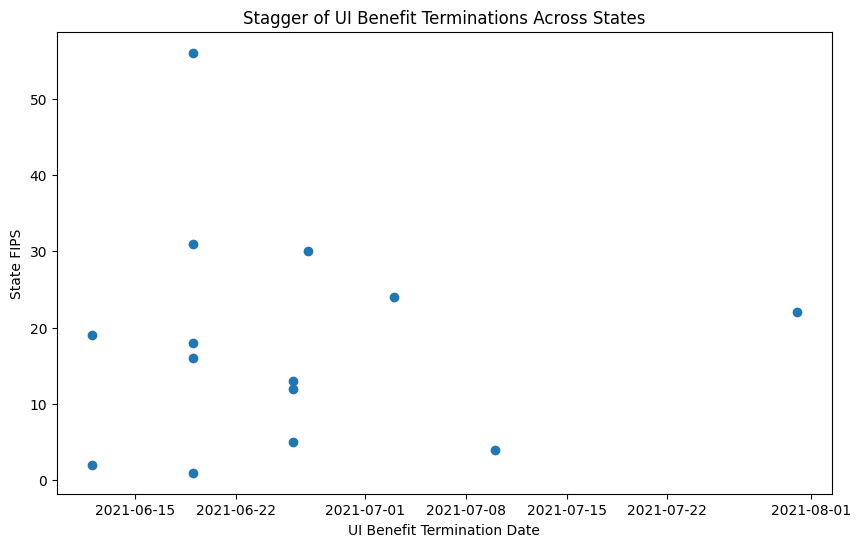

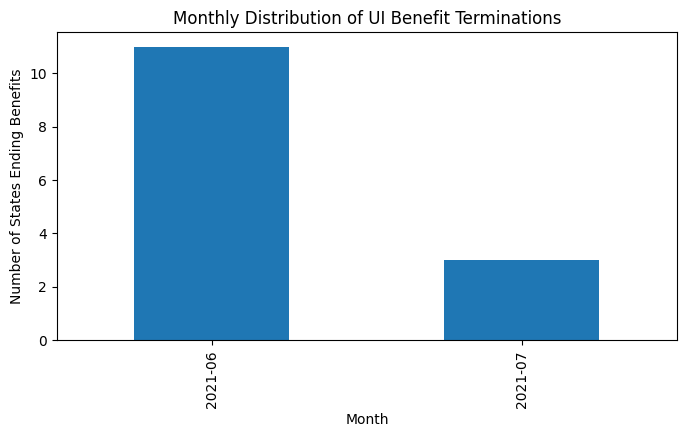

In [ ]:
import pandas as pd

# Assume panel_df has a 'statefips' and 'treatment_date' column
# Keep only unique state-treatment date pairs
state_treatment = (
    panel_df[['statefips', 'treatment_date']]
    .dropna()
    .drop_duplicates()
    .sort_values('treatment_date')
)

# Summary stats
print("Earliest termination:", state_treatment['treatment_date'].min())
print("Latest termination:", state_treatment['treatment_date'].max())
print("Range in days:", (state_treatment['treatment_date'].max() - state_treatment['treatment_date'].min()).days)

# Optional: visualize stagger
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(state_treatment['treatment_date'], state_treatment['statefips'])
plt.xlabel("UI Benefit Termination Date")
plt.ylabel("State FIPS")
plt.title("Stagger of UI Benefit Terminations Across States")
plt.show()

# Optional: histogram of terminations
plt.figure(figsize=(8,4))
state_treatment['treatment_date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar')
plt.xlabel("Month")
plt.ylabel("Number of States Ending Benefits")
plt.title("Monthly Distribution of UI Benefit Terminations")
plt.show()


In [ ]:
import pandas as pd
from linearmodels.panel import PanelOLS
import numpy as np

# ---------------------------
# 0) Ensure your date columns are datetime
# ---------------------------
panel_df['treatment_date'] = pd.to_datetime(panel_df['treatment_date'])
panel_df['week'] = panel_df.index.get_level_values('date')

# ---------------------------
# 1) Define early vs late states relative to September expiration
# ---------------------------
federal_expiration = pd.Timestamp('2021-09-06')  # Example federal UI expiration date

# Compute distance in days from federal expiration
panel_df['days_from_sep_exp'] = (federal_expiration - panel_df['treatment_date']).dt.days

# Define bins
# e.g., early = >60 days before, mid = 30-60 days before, late = <30 days before
panel_df['ui_bin'] = pd.cut(
    panel_df['days_from_sep_exp'],
    bins=[-np.inf, 30, 60, np.inf],
    labels=['late', 'mid', 'early']
)

# ---------------------------
# 2) Create binary treatment: 1 if early, 0 if late
# ---------------------------
panel_df['Policy_DiD'] = (panel_df['ui_bin'] == 'early').astype(int)

# Optional: create event_time relative to treatment
panel_df['event_time'] = (panel_df['week'] - panel_df['treatment_date']).dt.days // 7

# ---------------------------
# 3) Model: TWFE with clustered standard errors
# ---------------------------
# Example for emp_incq1
y = panel_df['emp_incq1']
X = panel_df[['Policy_DiD', 'covid_severity']]
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res)
print("\nPolicy effect (early vs late):", res.params['Policy_DiD'])
print("P-value:", res.pvalues['Policy_DiD'])

# ---------------------------
# 4) Optional: Event-study coefficients
# ---------------------------
event_dummies = pd.get_dummies(panel_df['event_time'], prefix='T')
X_event = pd.concat([panel_df[['covid_severity']], event_dummies], axis=1)
mod_event = PanelOLS(y, X_event, entity_effects=True, time_effects=True)
res_event = mod_event.fit(cov_type='clustered', cluster_entity=True)


KeyError: 'Requested level (date) does not match index name (None)'

In [ ]:
panel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58807 entries, 0 to 58806
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   level_0            58807 non-null  int64         
 1   index              58807 non-null  int64         
 2   statefips          58807 non-null  int64         
 3   date               58807 non-null  datetime64[ns]
 4   year               58807 non-null  int64         
 5   month              58807 non-null  int64         
 6   day                58807 non-null  int64         
 7   countyfips         58807 non-null  int64         
 8   emp                36952 non-null  float64       
 9   emp_incq1          23343 non-null  float64       
 10  emp_incq2          26753 non-null  float64       
 11  emp_incq3          24304 non-null  float64       
 12  emp_incq4          18755 non-null  float64       
 13  emp_incmiddle      31992 non-null  float64       
 14  emp_in

In [5]:
import pandas as pd
from linearmodels.panel import PanelOLS

# -----------------------
# Ensure MultiIndex
# -----------------------
# Assuming panel_df has 'statefips' and 'date' columns
panel_df = panel_df.set_index(['statefips', 'date'], drop=True)

# -----------------------
# Define outcome and regressors
# -----------------------
outcome = 'emp_incq1'  # loop later for others
X = panel_df[['Policy_DiD_Early', 'Policy_DiD_Mid', 'Policy_DiD_Late', 'covid_severity']]
y = panel_df[outcome]

# -----------------------
# Add constant to X
# -----------------------
import statsmodels.api as sm
X = sm.add_constant(X)

# -----------------------
# Run TWFE
# -----------------------
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res.summary)


KeyError: "None of ['date'] are in the columns"

In [ ]:
from linearmodels.panel import PanelOLS

# MultiIndex already set: ['statefips','date']
# Outcome
y = panel_df['emp_incq1']

# Regressors: drop one category as reference (e.g., 'Late')
X = panel_df[['Policy_DiD_Early','Policy_DiD_Mid','covid_severity']]

# Run TWFE without adding constant
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)
print(res.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:              emp_incq1   R-squared:                        0.0005
Estimator:                   PanelOLS   R-squared (Between):              0.0355
No. Observations:               23343   R-squared (Within):               0.0037
Date:                Fri, Oct 03 2025   R-squared (Overall):              0.0201
Time:                        23:50:22   Log-likelihood                    5144.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7442
Entities:                          51   P-value                           0.0105
Avg Obs:                       457.71   Distribution:                 F(3,23259)
Min Obs:                       31.000                                           
Max Obs:                       1736.0   F-statistic (robust):             1.9004
                            

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/linearmodels/panel/model.py:1260: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [6]:


# strict early cutoff
import pandas as pd
from linearmodels.panel import PanelOLS

federal = pd.Timestamp('2021-09-06')
early_cutoff = pd.Timestamp('2021-06-15')  # adjust to match literature

# one-time: make sure index is correct

# unique state treatment dates
state_treatment = (panel_df.reset_index()[['statefips','treatment_date']]
                   .dropna().drop_duplicates().set_index('statefips'))

# mark early states (boolean per state)
early_states = state_treatment[state_treatment['treatment_date'] <= early_cutoff].index.tolist()
panel_df['is_early_state'] = panel_df.reset_index()['statefips'].isin(early_states).astype(int).values

# policy after treatment
panel_df['post_treatment'] = (panel_df.reset_index()['date'] > panel_df.reset_index()['treatment_date']).astype(int).values
# Policy_DiD as before
panel_df['Policy_DiD'] = panel_df['is_treated_state'] * panel_df['post_treatment']

# interaction to test early effect (Early vs Others)
panel_df['Policy_DiD_Early'] = (panel_df['is_early_state'] * panel_df['post_treatment']).astype(int)

# model (no constant because of FE)
y = panel_df['emp_incq1']         # example outcome
X = panel_df[['Policy_DiD_Early','covid_severity']]
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)
print(res.summary)

# ✅ Safe index handling
if not isinstance(panel_df.index, pd.MultiIndex) or panel_df.index.names != ['statefips', 'date']:
    panel_df = panel_df.set_index(['statefips', 'date'])
else:
    panel_df = panel_df.copy()



KeyError: "['treatment_date'] not in index"

In [7]:
# Continuous timing approach
federal = pd.Timestamp('2021-09-06')
df = panel_df.reset_index()

# days_to_federal only meaningful for treated states; others NaN
df['days_to_federal'] = (federal - df['treatment_date']).dt.days

# create a continuous "treatment intensity" that equals days_to_federal for treated post, else 0
df['treatment_intensity'] = 0
mask = (~df['treatment_date'].isna()) & (df['date'] > df['treatment_date'])
df.loc[mask, 'treatment_intensity'] = df.loc[mask, 'days_to_federal']

# optionally scale (e.g., per 30 days)
df['treatment_intensity_30d'] = df['treatment_intensity'] / 30.0

# set MultiIndex again
df = df.set_index(['statefips','date'])

# Model: coefficient on treatment_intensity_30d shows per-30-day effect
y = df['emp_incq1']
X = df[['treatment_intensity_30d','covid_severity']]

mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)
print(res.summary)


KeyError: 'treatment_date'

In [8]:
# Replication-style pipeline: "Early exit (June) vs. others" DiD / TWFE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# ---------- User-tweakable cutoffs ----------
EARLY_CUTOFF = pd.Timestamp('2021-06-15')   # define "early" exit (matches literature convention)
FEDERAL_EXPIRATION = pd.Timestamp('2021-09-06')  # federal expiration date
SAMPLE_START = pd.Timestamp('2021-06-01')    # window start to focus on post-early-exit dynamics
SAMPLE_END = FEDERAL_EXPIRATION              # window end to avoid federal expiration contamination

# ---------- 0) Safe index handling & basic checks ----------
# Ensure panel_df has date and statefips columns accessible
panel_df = panel_df.reset_index()  # safe: will preserve cols if they already existed

# Quick diagnostic: list unique (state,treatment_date)
state_treatment = (
    panel_df[['statefips','treatment_date']]
    .dropna()
    .drop_duplicates()
    .sort_values('treatment_date')
)
print("Unique state treatment dates (snippet):")
print(state_treatment.head(10))
print("... total states with treatment_date:", state_treatment['statefips'].nunique())

# ---------- 1) Define early-exit states ----------
# States that had treatment_date and it is on-or-before EARLY_CUTOFF
early_states = state_treatment[state_treatment['treatment_date'] <= EARLY_CUTOFF]['statefips'].unique().tolist()
print(f"\nNumber of 'early' states (<= {EARLY_CUTOFF.date()}):", len(early_states))
print("Early statefips:", early_states)

# ---------- 2) Create analysis sample and flags ----------
df = panel_df.copy()

# Ensure datetime columns
df['date'] = pd.to_datetime(df['date'])
df['treatment_date'] = pd.to_datetime(df['treatment_date'])

# restrict to sample window: June 1 through federal expiration
mask_window = (df['date'] >= SAMPLE_START) & (df['date'] <= SAMPLE_END)
df = df.loc[mask_window].copy()
print("\nObservations in sample window:", len(df))

# indicator: state is an early-exit state (time-invariant)
df['is_early_state'] = df['statefips'].isin(early_states).astype(int)

# define post period relative to each state's own treatment_date
# For states without treatment_date (treated only at federal expiration), this is False
df['post_state_treatment'] = False
mask_has_td = ~df['treatment_date'].isna()
df.loc[mask_has_td, 'post_state_treatment'] = (df.loc[mask_has_td, 'date'] > df.loc[mask_has_td, 'treatment_date']).astype(int)

# Our DiD treatment: Early states * post period (i.e., early states after they terminated)
df['Policy_DiD_Early'] = ((df['is_early_state'] == 1) & (df['post_state_treatment'] == 1)).astype(int)

# For comparability, create a generic Policy_DiD (any treated state post-treatment) as well
df['is_treated_state'] = (~df['treatment_date'].isna()).astype(int)
df['Policy_DiD_any'] = ((df['is_treated_state'] == 1) & (df['post_state_treatment'] == 1)).astype(int)

# ---------- 3) Aggregate to state-week (to mimic state-level design) ----------
# If your data are county-level, aggregate by state-week (mean of quantile shares).
# If your data are already state-week, this will collapse to the same.
group_cols = ['statefips','date']
agg_cols = [
    'emp_incq1','emp_incq2','emp_incq3','emp_incq4',
    'emp_incmiddle','emp_incbelowmed','emp_incabovemed',
    'covid_severity',
    'is_early_state','is_treated_state',
    'Policy_DiD_Early','Policy_DiD_any'
]

# keep only available columns
agg_cols = [c for c in agg_cols if c in df.columns]
state_week = df.groupby(group_cols)[agg_cols].mean().reset_index()  # mean across counties

# Recreate flags as integer (mean may produce 0/1 floats)
for flag in ['is_early_state','is_treated_state','Policy_DiD_Early','Policy_DiD_any']:
    if flag in state_week:
        state_week[flag] = (state_week[flag] >= 0.5).astype(int)

# Set MultiIndex for PanelOLS
state_week = state_week.set_index(['statefips','date']).sort_index()

# Diagnostics: how many states labelled early vs others
print("\nStates labelled early (count):", state_week.reset_index().groupby('statefips')['is_early_state'].max().sum())
print("States with any treatment_date present:", len(state_treatment))

# ---------- 4) Run TWFE (Early vs Others) for each outcome (state-week aggregation) ----------
outcomes = [c for c in ['emp_incq1','emp_incq2','emp_incq3','emp_incq4',
                       'emp_incmiddle','emp_incbelowmed','emp_incabovemed'] if c in state_week.columns]

twfe_results = {}
for outcome in outcomes:
    # drop NA rows for y and key controls
    df_model = state_week[[outcome,'Policy_DiD_Early','covid_severity']].dropna()
    if df_model.empty:
        print("No data for", outcome)
        continue

    y = df_model[[outcome]]   # DataFrame to be safe
    X = df_model[['Policy_DiD_Early','covid_severity']]  # no constant; FE absorbs it

    mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    twfe_results[outcome] = res

    print("\n--- Outcome:", outcome, "---")
    print(res.summary)
    print("Policy_DiD_Early coef:", res.params.get('Policy_DiD_Early'))
    print("pval:", res.pvalues.get('Policy_DiD_Early'))

# ---------- 5) Quick event-study check for the "early" design ----------
# We can compute event-time coefficients using T_-8..T_8 dummies already present in your master data (but here focused on early states)
# Build event-study using only the early states (treated) and control states (non-early) in the June->Sept window.
es_cols = [f'T_{t}' for t in range(-8,9) if f'T_{t}' in panel_df.columns]
if es_cols:
    # restrict to rows used in state_week but from original df (county-level); average to state-week as before
    es_df = panel_df.loc[ (panel_df['date'] >= SAMPLE_START) & (panel_df['date'] <= SAMPLE_END) , ['statefips','date'] + es_cols + ['is_early_state','emp_incq1'] ]
    es_state = es_df.groupby(['statefips','date'])[es_cols + ['is_early_state','emp_incq1']].mean().reset_index()
    # separate early vs controls and run OLS of emp on the event dummies interacting with early-state flag
    # create interacted dummies:
    for col in es_cols:
        es_state[f'{col}_early'] = es_state[col] * es_state['is_early_state']
    Xcols = [f'{c}_early' for c in es_cols]
    X = sm.add_constant(es_state[Xcols].fillna(0))
    y = es_state['emp_incq1'].fillna(0)
    est = sm.OLS(y, X).fit(cov_type='HC1')
    coefs = est.params.filter(like='_early')
    ci = est.conf_int().loc[coefs.index]
    plt.figure(figsize=(8,4))
    weeks = [int(name.split('_')[1]) for name in coefs.index]
    plt.errorbar(weeks, coefs.values, yerr=[coefs.values - ci[0].values, ci[1].values - coefs.values], fmt='o', capsize=4)
    plt.axvline(-0.5, color='gray', linestyle='--')
    plt.axhline(0, color='k', linestyle='--')
    plt.xlabel('Weeks relative to state termination')
    plt.ylabel('Effect (Early states interaction)')
    plt.title('Event-study (Early states interacted) — emp_incq1')
    plt.show()
else:
    print("Event-study columns T_-8..T_8 not present; skipping ES plot.")


KeyError: "['treatment_date'] not in index"

In [10]:
# ============================================
# 1. Setup
# ============================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels import PanelOLS

# Load your merged Opportunity Insights + policy + covid dataset
# (replace with your actual file path)
panel_df = pd.read_csv("merged_panel_baseline.csv", parse_dates=['date', 'treatment_date'])

# ============================================
# 2. Check for key columns
# ============================================
expected_cols = {'statefips','date','treatment_date','emp_incq1','covid_severity'}
missing = expected_cols - set(panel_df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Make sure it’s indexed correctly
panel_df = panel_df.set_index(['statefips','date']).sort_index()

# ============================================
# 3. Define policy exit timing categories
# ============================================

# Define policy cutoff dates
federal_end = pd.Timestamp("2021-09-06")     # official federal expiration
early_cutoff = pd.Timestamp("2021-06-15")    # common literature cutoff (Chetty, Coombs, Hoynes)

def classify_treatment_date(date):
    if pd.isna(date):
        return "never"
    elif date < early_cutoff:
        return "early"
    elif date < federal_end:
        return "mid"
    else:
        return "federal"

panel_df['exit_group'] = panel_df['treatment_date'].apply(classify_treatment_date)

# ============================================
# 4. Create policy indicators
# ============================================

panel_df['Policy_DiD_Early'] = np.where(
    (panel_df['exit_group'] == 'early') &
    (panel_df.index.get_level_values('date') >= panel_df['treatment_date']), 1, 0
)

panel_df['Policy_DiD_Mid'] = np.where(
    (panel_df['exit_group'] == 'mid') &
    (panel_df.index.get_level_values('date') >= panel_df['treatment_date']), 1, 0
)

# Optional single combined policy flag for reference
panel_df['Policy_DiD'] = np.where(
    (panel_df['exit_group'].isin(['early','mid'])) &
    (panel_df.index.get_level_values('date') >= panel_df['treatment_date']), 1, 0
)

# ============================================
# 5. Quick validation checks
# ============================================
print("\nTreatment group counts:")
print(panel_df['exit_group'].value_counts(dropna=False))
print("\nUnique treated states:")
print(panel_df.reset_index().query("Policy_DiD == 1")['statefips'].nunique())

# ============================================
# 6. Baseline TWFE regression
# ============================================

y = panel_df['emp_incq1']
X = panel_df[['Policy_DiD_Early', 'Policy_DiD_Mid', 'covid_severity']]
X = sm.add_constant(X)

mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n=== Baseline TWFE Results ===")
print(res.summary)

# ============================================
# 7. (Optional) Check treatment timing visually
# ============================================
# For a quick verification that your treatment is staggered:
treat_dates = panel_df.reset_index().groupby('statefips')['treatment_date'].first()
print("\nTreatment dates by state:")
print(treat_dates.sort_values())


FileNotFoundError: [Errno 2] No such file or directory: 'merged_panel_baseline.csv'

In [15]:
# =========================================================
# BASELINE PANEL REBUILD (with COVID State Daily)
# =========================================================
import pandas as pd
import numpy as np
import os
from linearmodels import PanelOLS
import statsmodels.api as sm

# -----------------------
# Path setup
# -----------------------
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

EMP_FILE = os.path.join(DOWNLOADS_PATH, 'Employment - State - Weekly.csv')
COVID_FILE = os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv')
POLICY_FILE = os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv')

# -----------------------
# Load CSVs
# -----------------------
emp = pd.read_csv(EMP_FILE)
covid = pd.read_csv(COVID_FILE)
policy = pd.read_csv(POLICY_FILE)

# -----------------------
# Date handling
# -----------------------
emp['date'] = pd.to_datetime(emp['date'], errors='coerce')
covid['date'] = pd.to_datetime(covid['date'], errors='coerce')

# -----------------------
# FIPS consistency
# -----------------------
for df in [emp, covid, policy]:
    if 'statefips' not in df.columns:
        df['statefips'] = df['state'].astype('category').cat.codes + 1

# -----------------------
# Convert COVID daily → weekly to align with employment data
# -----------------------
covid_weekly = (
    covid
    .set_index('date')
    .groupby(['statefips'])
    .resample('W')
    .agg({'covid_confirmed': 'sum'})
    .reset_index()
)

# -----------------------
# Merge datasets
# -----------------------
panel_df = (
    emp.merge(covid_weekly, on=['statefips', 'date'], how='left', suffixes=('', '_covid'))
       .merge(policy, on='statefips', how='left')
)

# -----------------------
# Treatment timing
# -----------------------
federal = pd.Timestamp('2021-09-06')
early_cutoff = pd.Timestamp('2021-06-15')

panel_df['treatment_date'] = pd.to_datetime(panel_df['treatment_date'], errors='coerce')
panel_df = panel_df.dropna(subset=['treatment_date'])

panel_df['early_exit'] = panel_df['treatment_date'] < early_cutoff
panel_df['post_policy'] = panel_df['date'] >= panel_df['treatment_date']
panel_df['Policy_DiD_Early'] = panel_df['early_exit'] * panel_df['post_policy']

# -----------------------
# Select relevant variables
# -----------------------
panel_df = panel_df[['statefips', 'date', 'emp_incq1', 'covid_confirmed', 'Policy_DiD_Early']].dropna()
panel_df = panel_df.set_index(['statefips', 'date'])

# -----------------------
# Run baseline TWFE model
# -----------------------
y = panel_df['emp_incq1']
X = panel_df[['Policy_DiD_Early', 'covid_confirmed']]
X = sm.add_constant(X)

mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res.summary)

# -----------------------
# Sanity check: included states
# -----------------------
early_states = policy.loc[policy['treatment_date'] < early_cutoff, 'state'].unique()
print(f"\nEarly states included ({len(early_states)}): {list(early_states)}")


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_83803/3166967280.py:23: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid = pd.read_csv(COVID_FILE)


KeyError: 'date'

In [16]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14127 entries, 0 to 14126
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             14127 non-null  int64 
 1   month            14127 non-null  int64 
 2   day_endofweek    14127 non-null  int64 
 3   statefips        14127 non-null  int64 
 4   emp              14127 non-null  object
 5   emp_incq1        14127 non-null  object
 6   emp_incq2        14127 non-null  object
 7   emp_incq3        14127 non-null  object
 8   emp_incq4        14127 non-null  object
 9   emp_incmiddle    14127 non-null  object
 10  emp_incbelowmed  14127 non-null  object
 11  emp_incabovemed  14127 non-null  object
 12  emp_ss40         14127 non-null  object
 13  emp_ss60         14127 non-null  object
 14  emp_ss65         14127 non-null  object
 15  emp_ss70         14127 non-null  object
dtypes: int64(4), object(12)
memory usage: 1.7+ MB


In [17]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104016 entries, 0 to 104015
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     104016 non-null  int64 
 1   month                    104016 non-null  int64 
 2   day                      104016 non-null  int64 
 3   statefips                104016 non-null  int64 
 4   new_case_count           104016 non-null  object
 5   new_death_count          104016 non-null  object
 6   case_count               104016 non-null  object
 7   death_count              104016 non-null  object
 8   vaccine_count            104016 non-null  object
 9   fullvaccine_count        104016 non-null  object
 10  booster_first_count      104016 non-null  object
 11  new_vaccine_count        104016 non-null  object
 12  new_fullvaccine_count    104016 non-null  object
 13  new_booster_first_count  104016 non-null  object
 14  new_test_count      

In [18]:
# =========================================================
# CLEANUP + VISUALIZATION: Early vs. Late States Employment
# =========================================================
import matplotlib.pyplot as plt

# -----------------------
# Convert employment columns to numeric
# -----------------------
for col in ['emp_incq1', 'emp_incq2', 'emp_incq3', 'emp_incq4',
            'emp_incmiddle', 'emp_incbelowmed', 'emp_incabovemed']:
    if col in emp.columns:
        emp[col] = pd.to_numeric(emp[col], errors='coerce')

# -----------------------
# Define early vs late
# -----------------------
early_states = policy.loc[policy['treatment_date'] < pd.Timestamp('2021-06-15'), 'statefips']
emp['early_exit'] = emp['statefips'].isin(early_states)
emp['date'] = pd.to_datetime(emp[['year', 'month', 'day_endofweek']])

# -----------------------
# Compute group means over time
# -----------------------
emp_grouped = (
    emp.groupby(['date', 'early_exit'])['emp_incq1']
    .mean()
    .reset_index()
)

# -----------------------
# Plot pre/post trends
# -----------------------
plt.figure(figsize=(10, 6))
for label, group in emp_grouped.groupby('early_exit'):
    plt.plot(group['date'], group['emp_incq1'],
             label='Early Exit' if label else 'Late Exit', linewidth=2)

plt.axvline(pd.Timestamp('2021-06-15'), color='red', linestyle='--', label='Early Cutoff')
plt.axvline(pd.Timestamp('2021-09-06'), color='gray', linestyle=':', label='Federal End')
plt.title('Employment (Lowest Quartile) Trends: Early vs. Late Exit States', fontsize=14)
plt.ylabel('Employment Rate (emp_incq1)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'treatment_date'